In [1]:
from torchvision.datasets import CelebA
from torchvision import transforms

from torchvision.models import ResNet18_Weights

import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import random_split


from torchmetrics.classification import BinaryAUROC, Accuracy

import torch
from pytorch_lightning.loggers import WandbLogger

import numpy as np 

import wandb

from datetime import datetime
from tqdm.notebook import tqdm

from collections import OrderedDict

from xaikd import utils, attributors, models

import pandas as pd

from matplotlib import pyplot as plt 

In [2]:
DATA_ROOT = "../../datasets"

WANDB_PROJECT = "xaikd-training-teacher-models"
WANDB_GROUP = "celeba"

NUM_WORKERS = 16
BATCH_SIZE = 64
NUM_ATTRIBUTES = 40

TRAINING_SIZE = 0.1

SEED = 1

DEVICE = "cuda"

ARCH = "resnet18"

RUN_ID = "n8r0q2vb"
# RUN_ID = "dskgwbyk" # fc.bias= False


WANDB_PROJECT = "kitchen-sink"
RUN_ID = "jtp7uv29"

In [3]:
TRANSFORMATION_DEFAULT = ResNet18_Weights.IMAGENET1K_V1.transforms()

In [4]:
TRANSFORMATION_DEFAULT.mean, TRANSFORMATION_DEFAULT.std

([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

In [5]:
ds_train = CelebA(
    root=DATA_ROOT, split="train", target_type="attr",
    transform=TRANSFORMATION_DEFAULT
)

trng = torch.Generator()
trng.manual_seed(1)
ds_train, _ = random_split(ds_train, [TRAINING_SIZE, 1-TRAINING_SIZE], generator=trng)

dl_train = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,    
    shuffle=False,
)

In [6]:
ds_val = CelebA(
    root=DATA_ROOT, split="valid", target_type="attr",
    transform=TRANSFORMATION_DEFAULT
)

ds_val, _ = random_split(ds_val, [TRAINING_SIZE, 1-TRAINING_SIZE], generator=trng)

dl_val = DataLoader(
    ds_val,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,    
    shuffle=False,
)

In [8]:
class MultiTaskHead(nn.Module):
    def __init__(self, in_dims, num_tasks, out_per_task):
        super().__init__()
        
        arr_heads = []
        for tix in range(num_tasks):
            head = nn.Linear(in_features=in_dims, out_features=out_per_task)
            arr_heads.append(head)
        self.arr_heads = nn.ModuleList(arr_heads)
        self.task_id = None

    def forward(self, x):
        if self.task_id is not None:
            return self.arr_heads[self.task_id](x)
    
        arr_out = []

        
        for head in self.arr_heads:
            headout = head(x)
            b, d = headout.shape
            arr_out.append(headout.reshape(b, 1, d))

        out = torch.cat(arr_out, dim=1)
        return out
        
def get_state_dict(run_id):
    agent = wandb.Api()

    artifact: wandb.Artifact = agent.artifact(
        f"{WANDB_PROJECT}/model-{RUN_ID}:latest"
    )

    artifact_dir = artifact.download(root="/tmp")

    ckpt = torch.load(
        f"{artifact_dir}/model.ckpt",
        map_location=torch.device("cpu"),
        weights_only=False,
    )

    state_dict = ckpt["state_dict"]

    new_dict = OrderedDict()
    for k, v in state_dict.items():
        new_k = k.replace("encoder.", "")
        new_dict[new_k] = v
        
    return new_dict

def get_model(arch):



    state_dict = get_state_dict(RUN_ID)
    
    if arch == "resnet18":
        model = torchvision.models.resnet18(weights=None, num_classes=NUM_ATTRIBUTES)
        out_dims, in_dims = model.fc.weight.shape
        
        model.fc = MultiTaskHead(in_dims, NUM_ATTRIBUTES, 2)
    
    model.load_state_dict(state_dict)

    model.eval()
    model.to(DEVICE)
    
    return model
    
model = get_model(ARCH);

wandb: Downloading large artifact model-jtp7uv29:latest, 128.59MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.5


In [9]:
def estimate_task_performance(model, dl, task_id, verbose=False):

    metric = Accuracy(task="multiclass", num_classes=2)
    # metric = BinaryAUROC(thresholds=20)
    model.to(DEVICE)

    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        task_logit = model(x)[:, task_id].cpu()
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)

    metric = float(metric.compute())
    # metric = np.max([metric, 1-metric])
    return metric

# cross-check with wandb that we have correct results
estimate_task_performance(model, dl_val, task_id=0, verbose=True)

  0%|          | 0/32 [00:00<?, ?it/s]

0.9350780248641968

# Extract Activation and Context Vectors for Task

In [13]:
class VoidAttributor:

    def __enter__(self, **kwargs):
        pass

    def __exit__(self, type, value, tb):
        pass


def extract_activation_context_for_task(
    model: nn.Module,
    layer: str,
    data_loader: DataLoader,
    task_id: int,
    use_lrp=True,
    seed=1,
    device=DEVICE,
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):
        
    arr_act = []
    arr_ctx = []

    rng = np.random.default_rng(seed=1)

    logit_mod = attributors.WinningClassEvidence(num_classes=2)
    task_query_vector = F.one_hot(torch.tensor(task_id), num_classes=NUM_ATTRIBUTES).to(DEVICE)
    try:
        model.fc.task_id = task_id
        
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        attributor = attributors.make_attributor_for(
            model,
            (
                TRANSFORMATION_DEFAULT.mean, TRANSFORMATION_DEFAULT.std
            )
        ) if use_lrp else VoidAttributor()
        
        with attributor:
            for batch in tqdm(data_loader, desc=f"[layer={layer}; use_lrp={use_lrp}] extract act ctx"):
                x, y = batch
                x = x.to(device)

                if use_lrp:
                    _ = attributor.forward(x, lambda logits: logit_mod(logits, y))
    
                    act = utils.interceptor.get_output(module)
    
                    assert act.grad is not None
                    rel = act.grad
    
    
                    ctx = torch.where(act.abs() > 0, rel / act, 0)
                    assert torch.isfinite(ctx).all()
                    
                    if strict_mode:
                        np.testing.assert_allclose(
                            (act * ctx).detach().cpu().numpy(),
                            rel.detach().cpu().numpy(),
                            atol=1e-6,
                        )
                else:
                    logits = model(x)
                    (logits).sum().backward()
                    act = utils.interceptor.get_output(module)
    
                    assert act.grad is not None
                    ctx = act.grad
                
                output_dimensions = act.shape[1:]


                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()
        model.fc.task_id = None

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx

def ano():

    for use_lrp in [True, False]:
        

        extract_activation_context_for_task(
            model, 
            "layer1",
            dl_train,
            task_id=0,
            use_lrp=use_lrp
        )
        
    print("Sanity check: passed!")
ano()

[layer=layer1; use_lrp=True] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 56, 56])


[layer=layer1; use_lrp=False] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 56, 56])
Sanity check: passed!


## Constructing Basis 

In [14]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs

def estimate_basis(basis_name, arr_act, arr_ctx):
    if basis_name == "pca":
        cov = arr_act.T @ arr_act
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    elif basis_name == "gpca":
        cov = arr_ctx.T @ arr_ctx
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    elif basis_name == "v0":
        w = model.fc.weight[0, :].detach().cpu().numpy()
        w = w / np.linalg.norm(w)
        U = w.reshape((-1, 1))
        return U
    elif basis_name == "prca":
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    elif basis_name == "prca-sortabs":
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        eigvecs = _solve_eigvecs(cov, sort_func=np.abs)
        return eigvecs
    else:
        raise

In [1]:
raise

RuntimeError: No active exception to reraise

## Estimating AUROCs

In [15]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_aurocs_at_k(
    model, layer, task_id, arr_ks,
    use_lrp,
    arr_basis_names=[
        "pca", 
        "prca-sortabs",
        "gpca",
    ]
):
    arr_act, arr_ctx = extract_activation_context_for_task(
        model=model, 
        layer=layer, 
        data_loader=dl_train, 
        task_id=task_id,
        use_lrp=use_lrp
    )
    arr_stat_rows = []
    
    module = getattr(model, layer)
    
    for basis_name in arr_basis_names:
        U = estimate_basis(basis_name, arr_act, arr_ctx)
        for k in tqdm(arr_ks, desc=f"[basis={basis_name}] compute task performance at k"):
            Uk = torch.from_numpy(U[:, :k]).to(DEVICE)
            row = dict(
                layer=layer,
                use_lrp=use_lrp,
                task_id=task_id, 
                basis_name=basis_name,
                k=k,
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    # ("train", dl_train_noshuffle),
                    ("val", dl_val)
                ]:
                    row[f"{label}_acc"] = estimate_task_performance(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
    df = pd.DataFrame(arr_stat_rows)
    
    return df

compute_task_aurocs_at_k(model, layer="layer2", task_id=0, arr_ks=np.arange(1, 10).tolist() + [128], use_lrp=True)

[layer=layer2; use_lrp=True] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer2: output-dims=torch.Size([128, 28, 28])


[basis=pca] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

[basis=prca-sortabs] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

[basis=gpca] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

,layer,use_lrp,task_id,basis_name,k,val_acc
0,layer2,True,0,pca,1,0.881228
1,layer2,True,0,pca,2,0.881228
2,layer2,True,0,pca,3,0.881228
3,layer2,True,0,pca,4,0.881228
4,layer2,True,0,pca,5,0.881228
5,layer2,True,0,pca,6,0.889280
6,layer2,True,0,pca,7,0.900856
7,layer2,True,0,pca,8,0.907398
8,layer2,True,0,pca,9,0.917967
9,layer2,True,0,pca,128,0.935078


In [16]:
compute_task_aurocs_at_k(model, layer="layer2", task_id=0, arr_ks=np.arange(1, 10).tolist() + [128], use_lrp=False)

[layer=layer2; use_lrp=False] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer2: output-dims=torch.Size([128, 28, 28])


[basis=pca] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

[basis=prca-sortabs] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

[basis=gpca] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

,layer,use_lrp,task_id,basis_name,k,val_acc
0,layer2,False,0,pca,1,0.881228
1,layer2,False,0,pca,2,0.881228
2,layer2,False,0,pca,3,0.881228
3,layer2,False,0,pca,4,0.881228
4,layer2,False,0,pca,5,0.881228
5,layer2,False,0,pca,6,0.889280
6,layer2,False,0,pca,7,0.900856
7,layer2,False,0,pca,8,0.907398
8,layer2,False,0,pca,9,0.917967
9,layer2,False,0,pca,128,0.935078


In [17]:
compute_task_aurocs_at_k(model, layer="layer4", task_id=0, arr_ks=np.arange(1, 10).tolist() + [128], use_lrp=True)

[layer=layer4; use_lrp=True] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer4: output-dims=torch.Size([512, 7, 7])


[basis=pca] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

[basis=prca-sortabs] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

[basis=gpca] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

,layer,use_lrp,task_id,basis_name,k,val_acc
0,layer4,True,0,pca,1,0.881228
1,layer4,True,0,pca,2,0.881228
2,layer4,True,0,pca,3,0.881228
3,layer4,True,0,pca,4,0.881228
4,layer4,True,0,pca,5,0.879215
5,layer4,True,0,pca,6,0.875692
6,layer4,True,0,pca,7,0.872672
7,layer4,True,0,pca,8,0.900856
8,layer4,True,0,pca,9,0.900352
9,layer4,True,0,pca,128,0.937091


In [19]:
compute_task_aurocs_at_k(model, layer="layer4", task_id=0, arr_ks=np.arange(1, 10).tolist() + [128], use_lrp=False)

[layer=layer4; use_lrp=False] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer4: output-dims=torch.Size([512, 7, 7])


[basis=pca] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

[basis=prca-sortabs] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

[basis=gpca] compute task performance at k:   0%|          | 0/10 [00:00<?, ?it/s]

,layer,use_lrp,task_id,basis_name,k,val_acc
0,layer4,False,0,pca,1,0.881228
1,layer4,False,0,pca,2,0.881228
2,layer4,False,0,pca,3,0.881228
3,layer4,False,0,pca,4,0.881228
4,layer4,False,0,pca,5,0.879215
5,layer4,False,0,pca,6,0.875692
6,layer4,False,0,pca,7,0.872672
7,layer4,False,0,pca,8,0.900856
8,layer4,False,0,pca,9,0.900352
9,layer4,False,0,pca,128,0.937091


In [18]:
raise

RuntimeError: No active exception to reraise

# Getting Results and Visualization

In [20]:
def getting_aurocs_for_tasks(task_id, arr_layers, use_lrp):
    arr_layer_dims = utils.get_dimensions_at_layers(
        model=model,
        dataloader=dl_train,
        layers=arr_layers,
        device=DEVICE
    )

    arr_dfs = []

    for layer in tqdm(arr_layers, desc="getting results for layer"):
        d = arr_layer_dims[layer]
        arr_ks = np.linspace(1, d, 8).astype(int)
        df = compute_task_aurocs_at_k(
            model, 
            layer=layer, 
            task_id=task_id, 
            arr_ks=arr_ks,
            use_lrp=use_lrp
        )
        
        arr_dfs.append(df)

    return pd.concat(arr_dfs)

df = getting_aurocs_for_tasks(
    task_id=0,
    arr_layers=["layer1", "layer2", "layer3", "layer4"],
    use_lrp=True
)

getting results for layer:   0%|          | 0/4 [00:00<?, ?it/s]

[layer=layer1; use_lrp=True] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 56, 56])


[basis=pca] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

[basis=prca-sortabs] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

...

[layer=layer4; use_lrp=True] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer4: output-dims=torch.Size([512, 7, 7])


[basis=pca] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

[basis=prca-sortabs] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

[basis=gpca] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

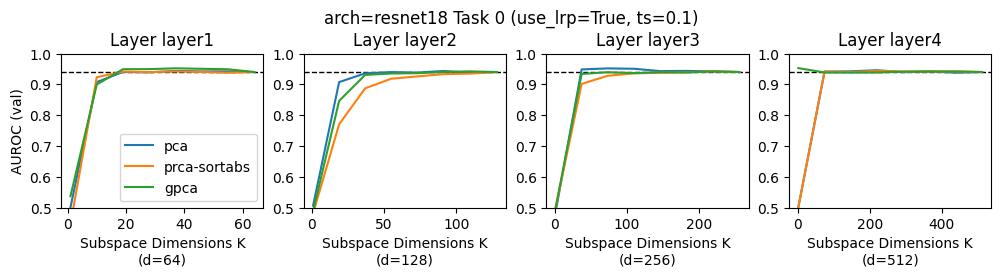

In [21]:
def viz_results(df):


    task_id = df.task_id.values[-1]
    arr_layers = df.layer.unique()
    ncols = len(arr_layers)

    use_lrp = df.use_lrp.values[-1]
    
    plt.figure(figsize=(3*ncols, 2))
    plt.suptitle(f"arch={ARCH} Task {task_id} (use_lrp={use_lrp}, ts={TRAINING_SIZE})", y=1.1)
    metric_col_name = "val_auroc"
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(f"Layer {layer}")

        for bix, basis_name in enumerate(["pca", "prca-sortabs", "gpca"]):
            
            _df = df[
                (df.task_id == task_id) & (df.basis_name == basis_name) & (df.layer == layer)
            ]
            if bix == 0:
                plt.axhline(
                    _df[metric_col_name].values[-1],
                    ls="--",
                    lw=1, 
                    color="k"
                )
            plt.plot(
                _df.k,
                _df[metric_col_name],
                label=basis_name
            )

            d = _df.k.values[-1]
            
        plt.ylim([0.5, 1.0])
        if lix == 0:
            plt.ylabel("AUROC (val)")
            plt.legend()
        plt.xlabel(f"Subspace Dimensions K\n(d={d})")

viz_results(df)

getting results for layer:   0%|          | 0/4 [00:00<?, ?it/s]

[layer=layer1; use_lrp=False] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 56, 56])


[basis=pca] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

[basis=prca-sortabs] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

...

[layer=layer4; use_lrp=False] extract act ctx:   0%|          | 0/255 [00:00<?, ?it/s]

layer4: output-dims=torch.Size([512, 7, 7])


[basis=pca] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

[basis=prca-sortabs] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

[basis=gpca] compute task performance at k:   0%|          | 0/8 [00:00<?, ?it/s]

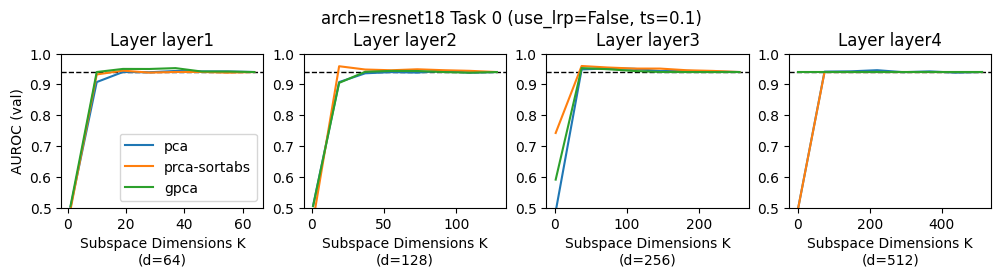

In [22]:
viz_results(getting_aurocs_for_tasks(
    task_id=0,
    arr_layers=["layer1", "layer2", "layer3", "layer4"],
    use_lrp=False
))

In [ ]:
for task_id in [10, 20, 30]:
    viz_results(getting_aurocs_for_tasks(
        task_id=task_id,
        arr_layers=["layer1", "layer2", "layer3", "layer4"],
        use_lrp=True
    ))

In [ ]:
print(f"finished at {datetime.now()}")

# Dev Notes
## 2024/12/17
- [x] get act/ctx
- [x] basis
- [x] forwardhook